# Data Cleaning & Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, mean_absolute_error
)
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb

from config import DATA_DIR

In [2]:
# Load the data
filepath = DATA_DIR / 'food_facts_raw.csv'
df = pd.read_csv(filepath)
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (31836, 114)


C:\Users\megan\AppData\Local\Temp\ipykernel_24700\1324236782.py:3: DtypeWarning: Columns (88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath)


,_id,ingredients_text,ecoscore_grade,languages_codes.en,ingredients_hierarchy[0],ingredients_hierarchy[1],ingredients_hierarchy[2],ingredients_hierarchy[3],ingredients_hierarchy[4],ingredients_hierarchy[5],...,ingredients_hierarchy[100],ingredients_hierarchy[101],ingredients_hierarchy[102],ingredients_hierarchy[103],ingredients_hierarchy[104],ingredients_hierarchy[105],ingredients_hierarchy[106],ingredients_hierarchy[107],ingredients_text_en,product_name_en
0,8.697400e+04,"White Cabbage (45%), Rapeseed Oil, Carrots (15...",a,1.0,en:white-cabbage,en:vegetable,en:brassica,en:cabbage,en:rapeseed-oil,en:oil-and-fat,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"White Cabbage (45%), Rapeseed Oil, Carrots (15...",NaN
1,3.339000e+05,"Kiwi, Strawberries, Banana, Mango",b,4.0,en:kiwi,en:fruit,en:strawberry,en:berries,en:banana,en:mango,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Kiwi, Strawberries, Banana, Mango",NaN
2,6.202000e+10,"Sucre, huile de palme modifiée, _noisettes_, c...",e,1.0,en:sugar,en:added-sugar,en:disaccharide,en:modified-palm-oil,en:oil-and-fat,en:vegetable-oil-and-fat,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,6.906500e+10,"Sardines, tomato sauce, sugar, salt, citric ac...",e,1.0,en:sardine,en:fish,en:oily-fish,en:tomato-sauce,en:sauce,en:sugar,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Sardines, tomato sauce, sugar, salt, citric ac...",NaN
4,9.699180e+05,Extra virgin olive oil.,e,3.0,en:extra-virgin-olive-oil,en:oil-and-fat,en:vegetable-oil-and-fat,en:vegetable-oil,en:olive-oil,en:virgin-olive-oil,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Extra virgin olive oil.,NaN


In [3]:
# Keep only columns of interest
df = df.drop(columns=['ingredients_text_en', 'languages_codes.en', 'product_name_en'])

In [4]:
# Find all ingredients_hierarchy columns
hierarchy_cols = [col for col in df.columns if col.startswith('ingredients_hierarchy')]

# Combine them into a single column (with dash-to-space replacement)
df['ingredients_combined'] = df[hierarchy_cols].apply(
    lambda row: ', '.join(
        str(val).replace('en:', '').replace('-', ' ').strip()
        for val in row
        if pd.notna(val) and val != ''
    ),
    axis=1
)

# Remove the old hierarchy columns
df = df.drop(columns=[*hierarchy_cols, 'ingredients_text'])

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31836 entries, 0 to 31835
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   _id                   31833 non-null  float64
 1   ecoscore_grade        31833 non-null  object 
 2   ingredients_combined  31836 non-null  object 
dtypes: float64(1), object(2)
memory usage: 746.3+ KB


In [6]:
# view the new combined data
# Set pandas to show full content
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)

# Now show all unique values
unique_ingredients = df['ingredients_combined'].unique()
print(f"Total unique combinations: {len(unique_ingredients)}")
print("\nAll unique combinations:")
for i, combo in enumerate(unique_ingredients, 1):
    print(f"{i}: {combo}")

# Reset display options if needed later
# pd.reset_option('display.max_colwidth')
# pd.reset_option('display.max_rows')

Total unique combinations: 15461

All unique combinations:
1: white cabbage, vegetable, brassica, cabbage, rapeseed oil, oil and fat, vegetable oil and fat, carrot, root vegetable, taproot vegetable, water, pasteurised egg yolk, egg, egg yolk, vinegar, sugar, added sugar, disaccharide, onion, onion family vegetable, potato starch, starch, salt, citrus fibre, fiber, vegetable fiber, egg white, mustard
2: kiwi, fruit, strawberry, berries, banana, mango
3: sugar, added sugar, disaccharide, modified palm oil, oil and fat, vegetable oil and fat, palm oil and fat, palm oil, hazelnut, nut, tree nut, cocoa, plant, skimmed milk powder, dairy, milk powder, whey powder, whey, soya and sunflower lecithin, e322, e322i, soya lecithin, sunflower lecithin, vanillin
4: sardine, fish, oily fish, tomato sauce, sauce, sugar, added sugar, disaccharide, salt, e330, black pepper, seed, pepper, spice, condiment, soya oil, oil and fat, vegetable oil and fat, vegetable oil
5: extra virgin olive oil, oil and fat

In [7]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())
print(f"\nMissing percentage:")
print((df.isnull().sum() / len(df) * 100).round(2))

Missing values:
_id                     3
ecoscore_grade          3
ingredients_combined    0
dtype: int64

Missing percentage:
_id                     0.01
ecoscore_grade          0.01
ingredients_combined    0.00
dtype: float64


In [12]:
# Remove rows with missing or whitespace-only values
df["ingredients_combined"] = df["ingredients_combined"].str.strip().replace("", np.nan)

print(f"Rows before dropping missing values: {len(df)}")
rows_before = len(df)
df = df.dropna(subset=["ingredients_combined"])
df = df.reset_index(drop=True)
rows_after = len(df)
print(f"Rows after dropping missing values: {rows_after}")
print(f"Rows removed: {rows_before - rows_after}")

Rows before dropping missing values: 31833
Rows after dropping missing values: 31738
Rows removed: 95


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31738 entries, 0 to 31737
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   _id                   31738 non-null  float64
 1   ecoscore_grade        31738 non-null  object 
 2   ingredients_combined  31738 non-null  object 
dtypes: float64(1), object(2)
memory usage: 744.0+ KB


In [14]:
# Save the cleaned dataset to processed folder
from config import PROCESSED_DIR
import os

# Create processed directory if it doesn't exist
os.makedirs(PROCESSED_DIR, exist_ok=True)

# Save the cleaned dataset
output_path = PROCESSED_DIR / 'food_facts_cleaned.csv'
df.to_csv(output_path, index=False)

print(f"Cleaned dataset saved to: {output_path}")
print(f"Final dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

Cleaned dataset saved to: c:\ecoml_project\data\processed\food_facts_cleaned.csv
Final dataset shape: (31738, 3)
Columns: ['_id', 'ecoscore_grade', 'ingredients_combined']


In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 31833 entries, 0 to 31835
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   _id                   31833 non-null  float64
 1   ecoscore_grade        31833 non-null  object 
 2   ingredients_combined  31833 non-null  object 
dtypes: float64(1), object(2)
memory usage: 994.8+ KB


# Visualisation

In [15]:
# Count of rows per eco-grade
print("Count of rows per eco-grade:")
eco_counts = df['ecoscore_grade'].value_counts()
print(eco_counts)
print(f"\nTotal rows: {eco_counts.sum()}")

Count of rows per eco-grade:
ecoscore_grade
d         10434
b          5560
a          5187
c          3987
e          3986
f          1822
a-plus      762
Name: count, dtype: int64

Total rows: 31738


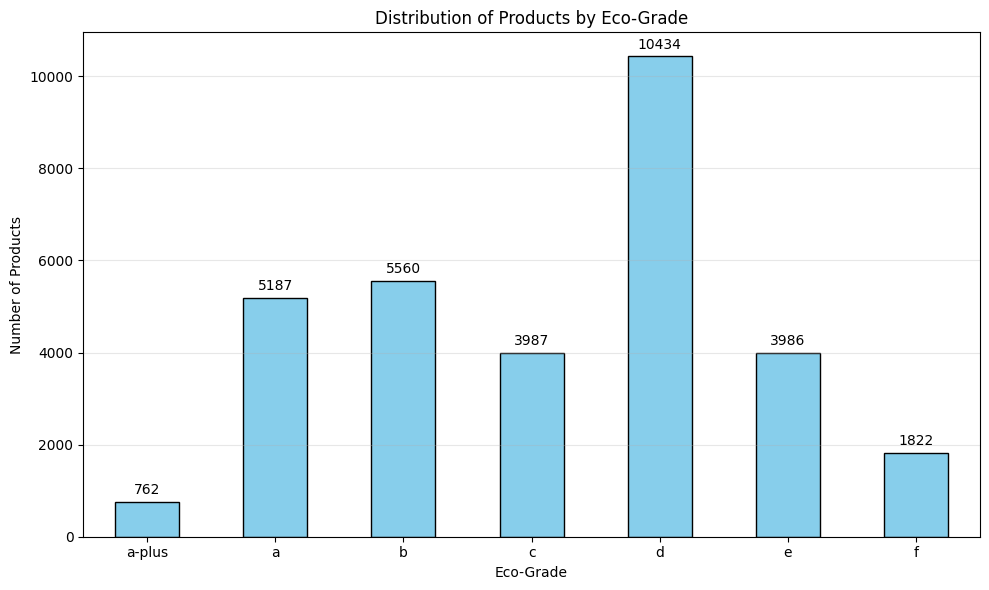

In [16]:
# Visualize eco-grade distribution (ordered alphabetically with a-plus first)
# Custom sort order: put a-plus first, then alphabetical
grade_order = sorted(eco_counts.index, key=lambda x: (x != 'a-plus', x))
eco_counts_ordered = eco_counts.reindex(grade_order)

plt.figure(figsize=(10, 6))
eco_counts_ordered.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Distribution of Products by Eco-Grade')
plt.xlabel('Eco-Grade')
plt.ylabel('Number of Products')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(eco_counts_ordered):
    plt.text(i, v + max(eco_counts_ordered) * 0.01, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

Average number of ingredients per eco-grade:
ecoscore_grade
a         10.19
a-plus     9.09
b         14.17
c         16.56
d         15.32
e         12.87
f          8.17
Name: ingredient_count, dtype: float64


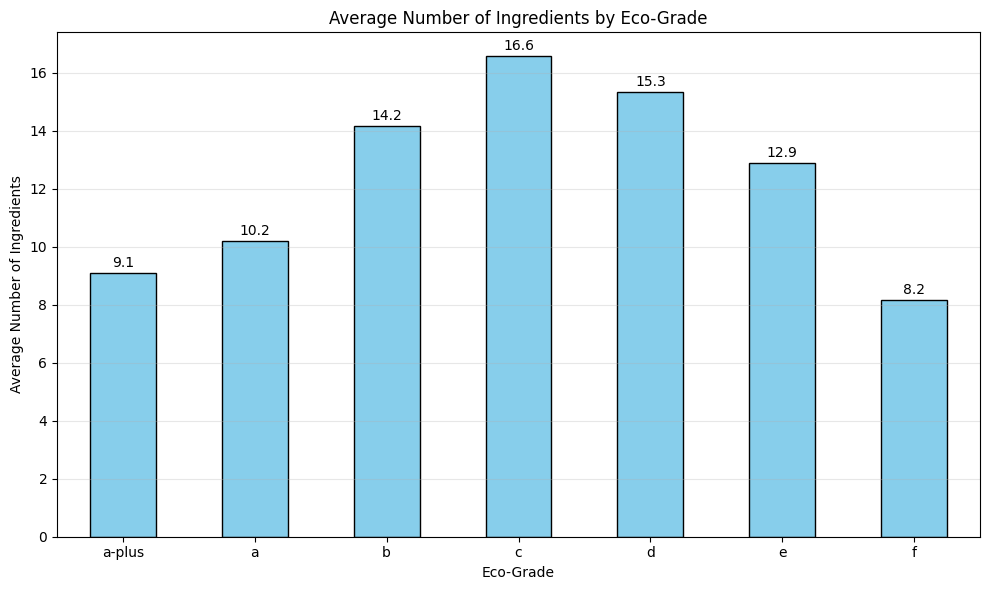

In [17]:
# Calculate average ingredients per eco-grade
df['ingredient_count'] = df['ingredients_combined'].str.split(',').str.len()
avg_ingredients_by_grade = df.groupby('ecoscore_grade')['ingredient_count'].mean().round(2)

print("Average number of ingredients per eco-grade:")
print(avg_ingredients_by_grade)

# Visualize (ordered like previous chart, same blue color)
grade_order = sorted(avg_ingredients_by_grade.index, key=lambda x: (x != 'a-plus', x))
avg_ingredients_ordered = avg_ingredients_by_grade.reindex(grade_order)

plt.figure(figsize=(10, 6))
avg_ingredients_ordered.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Average Number of Ingredients by Eco-Grade')
plt.xlabel('Eco-Grade')
plt.ylabel('Average Number of Ingredients')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

# Add value labels
for i, v in enumerate(avg_ingredients_ordered):
    plt.text(i, v + 0.1, f'{v:.1f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [18]:
# Extract most frequent ingredients per eco-grade
from collections import Counter

def get_top_ingredients(df_grade, top_n=10):
    """Get top N most frequent ingredients for a grade"""
    all_ingredients = []
    for ingredients_str in df_grade['ingredients_combined']:
        # Split by comma and clean
        ingredients = [ing.strip().lower() for ing in str(ingredients_str).split(',') if ing.strip()]
        all_ingredients.extend(ingredients)

    # Count frequencies
    ingredient_counts = Counter(all_ingredients)
    return ingredient_counts.most_common(top_n)

# Get unique grades
grades = sorted(df['ecoscore_grade'].unique(), key=lambda x: (x != 'a-plus', x))

print("Most frequent ingredients per eco-grade (top 10):")
print("=" * 60)

for grade in grades:
    df_grade = df[df['ecoscore_grade'] == grade]
    top_ingredients = get_top_ingredients(df_grade)

    print(f"\n{grade.upper()} Grade ({len(df_grade)} products):")
    for ingredient, count in top_ingredients:
        percentage = (count / len(df_grade)) * 100
        print(f"  {ingredient}: {count} ({percentage:.1f}%)")

Most frequent ingredients per eco-grade (top 10):

A-PLUS Grade (762 products):
  vegetable: 331 (43.4%)
  water: 197 (25.9%)
  salt: 196 (25.7%)
  added sugar: 172 (22.6%)
  root vegetable: 151 (19.8%)
  disaccharide: 144 (18.9%)
  fruit: 140 (18.4%)
  sugar: 138 (18.1%)
  fruit vegetable: 132 (17.3%)
  plant: 124 (16.3%)

A Grade (5187 products):
  vegetable: 2358 (45.5%)
  salt: 1806 (34.8%)
  added sugar: 1776 (34.2%)
  disaccharide: 1541 (29.7%)
  water: 1440 (27.8%)
  sugar: 1435 (27.7%)
  fruit vegetable: 1419 (27.4%)
  e330: 1209 (23.3%)
  tomato: 1127 (21.7%)
  fruit: 946 (18.2%)

B Grade (5560 products):
  added sugar: 2702 (48.6%)
  salt: 2486 (44.7%)
  vegetable: 2138 (38.5%)
  water: 2026 (36.4%)
  disaccharide: 1911 (34.4%)
  oil and fat: 1693 (30.4%)
  sugar: 1649 (29.7%)
  vegetable oil and fat: 1632 (29.4%)
  root vegetable: 1193 (21.5%)
  fruit: 1180 (21.2%)

C Grade (3987 products):
  salt: 2085 (52.3%)
  dairy: 1492 (37.4%)
  added sugar: 1477 (37.0%)
  disaccharide

Character count variation per eco-grade:
                  mean  median  min   max     std
ecoscore_grade                                   
a               111.74    66.0    3   820  114.46
a-plus           98.92    57.0    4   754  108.03
b               157.68    98.0    3  1237  152.87
c               181.16   114.0    3  1030  168.49
d               173.40   117.0    3  1330  155.35
e               145.21   102.0    3   988  139.05
f                90.42    43.0    4  1004  117.37


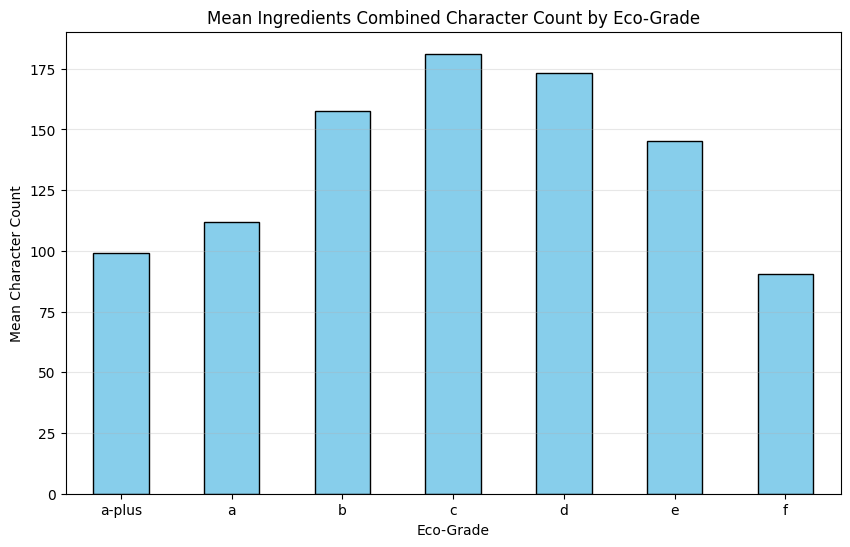


Token count distribution and >512 count
count    31738.00
mean        20.78
std         20.27
min          1.00
25%          7.00
50%         14.00
75%         27.00
max        177.00
Name: token_count, dtype: float64
Count above 512 tokens: 0


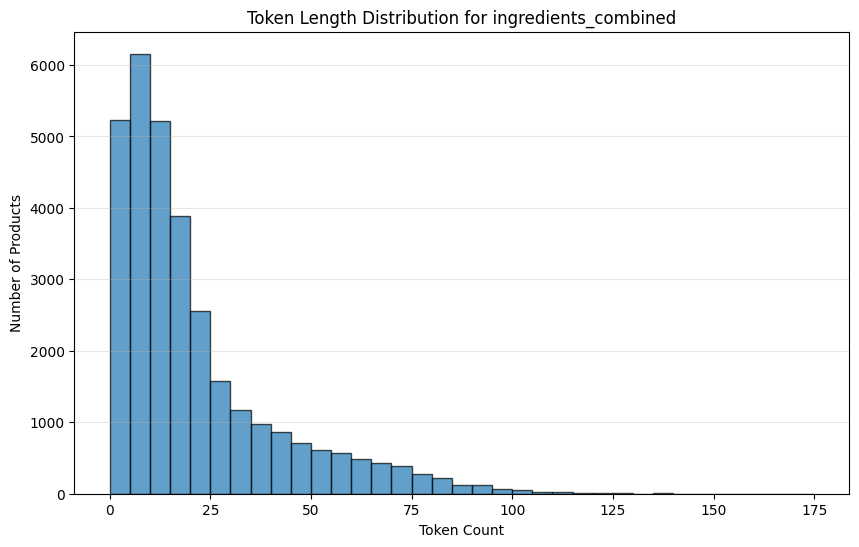

In [19]:
# Character count variation per eco-grade
print("Character count variation per eco-grade:")
df['char_count'] = df['ingredients_combined'].str.len()
char_stats_by_grade = df.groupby('ecoscore_grade')['char_count'].agg(['mean', 'median', 'min', 'max', 'std']).round(2)
print(char_stats_by_grade)

# Plot char count stats for eco-grade
plt.figure(figsize=(10, 6))
char_stats_by_grade['mean'].reindex(grade_order).plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Mean Ingredients Combined Character Count by Eco-Grade')
plt.xlabel('Eco-Grade')
plt.ylabel('Mean Character Count')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()

# Token length distribution with simple whitespace split (looking for token count to be less than 512 for BERT vectorisation)
print("\nToken count distribution and >512 count")
df['token_count'] = df['ingredients_combined'].apply(lambda x: len(str(x).split()))
token_counts = df['token_count']
token_summary = token_counts.describe().round(2)
above_512 = (token_counts > 512).sum()
print(token_summary)
print(f"Count above 512 tokens: {above_512}")

plt.figure(figsize=(10, 6))
plt.hist(token_counts, bins=range(0, min(200, token_counts.max()+1), 5), edgecolor='black', alpha=0.7)
plt.title('Token Length Distribution for ingredients_combined')
plt.xlabel('Token Count')
plt.ylabel('Number of Products')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [55]:
GRADE_ORDER = ["a-plus", "a", "b", "c", "d", "e", "f"]
df["ecoscore_grade"] = pd.Categorical(df["ecoscore_grade"], categories=GRADE_ORDER, ordered=True)
df = df.dropna(subset=["ingredients_combined", "ecoscore_grade"])
 
print("Class distribution:")
print(df["ecoscore_grade"].value_counts().sort_index())

Class distribution:
ecoscore_grade
a-plus      765
a          5200
b          5568
c          4013
d         10463
e          3998
f          1826
Name: count, dtype: int64
